## Basic

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('/home/pedrorozin/scripts/python')
import importlib
import torch
from scipy.integrate import simpson, solve_ivp
import delta_solver_mg_pedro
#reload para actualizar el módulo si se hacen cambios
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver

In [2]:
x = np.linspace(0, 2*np.pi, 10000000)
def sin_func(x):
	return np.sin(x)

integral = simpson(sin_func(x), x=x)
print("integral de sin(x) de 0 a 2pi =", integral)



integral de sin(x) de 0 a 2pi = 2.2368429637781757e-15


In [140]:
#usar cpu
device = torch.device('cpu')
print('Using device:', device)

Using device: cpu


In [141]:
import funciones_tesis as ft

M = ft.common_settings(h=0.68, omega_m=0.3, A_s=2e-9)
_sigma8=ft.get_sigma8(M)
print("sigma8 from class:", _sigma8)

sigma8 from class: 0.787709890469588


## Deltas

In [3]:
import funciones_tesis as ft
import importlib
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
import numpy as np
import matplotlib.pyplot as plt

In [4]:
h=0.68
mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 1000)/h  # k en 1/Mpc
solver = VectorizedDeltaSolver(k_array=mis_ks, h=h, Om_m_0=0.3, b=0.001)

VectorizedDeltaSolver usando: cuda


### Correr esto para generar y guardar soluciones (GUARDA. NO CORRER POR ERROR)

In [7]:
h = .68
mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 1000)/h  # k en 1/Mpc
solver = VectorizedDeltaSolver(k_array=mis_ks, h=h, Om_m_0=0.3, b=0.001)
a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel()
a_LCDM, delta_LCDM, delta_p_LCDM = solver.solve_delta_lcdm_vectorized_parallel()
z_mg = 1/a_mg - 1

VectorizedDeltaSolver usando: cuda
Resolviendo 1000 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1000 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.


In [ ]:
#guardar todos estos arrays de la manera mas eficiente para importarlos luego
path = '/home/pedrorozin/scripts/outputs_pedro/modified_gravity'
file_name = 'delta_mg_vs_k_and_z2.npz'
np.savez_compressed(path + f'/{file_name}', mis_ks=mis_ks, a_mg=a_mg, delta_mg=delta_mg, delta_p_mg=delta_p_mg,
					a_LCDM=a_LCDM, delta_LCDM=delta_LCDM, delta_p_LCDM=delta_p_LCDM, z_mg=z_mg)

#guardar info en un txt
with open(path + f'/{file_name}_info.txt', 'w') as f:
	f.write('Arrays guardados:\n')
	f.write('mis_ks: array de k en 1/Mpc\n')
	f.write('a_mg: array de a para MG\n')
	f.write('delta_mg: array de delta para MG\n')
	f.write('delta_p_mg: array de d(delta)/da para MG\n')
	f.write('a_LCDM: array de a para LCDM\n')
	f.write('delta_LCDM: array de delta para LCDM\n')
	f.write('delta_p_LCDM: array de d(delta)/da para LCDM\n')
	f.write('z_mg: array de z correspondiente a a_mg\n')
	f.write('\nDimensiones:\n')
	f.write(f'mis_ks: {mis_ks.shape}\n')
	f.write(f'a_mg: {a_mg.shape}\n')
	f.write(f'delta_mg: {delta_mg.shape}\n')
	f.write(f'delta_p_mg: {delta_p_mg.shape}\n')
	f.write(f'a_LCDM: {a_LCDM.shape}\n')
	f.write(f'delta_LCDM: {delta_LCDM.shape}\n')
	f.write(f'delta_p_LCDM: {delta_p_LCDM.shape}\n')
	f.write(f'z_mg: {z_mg.shape}\n')
	f.write(f'\nParametros usados:\n')
	f.write(f'h: {solver.h}\n')
	f.write(f'Om_m_0: {solver.Om_m_0}\n')
	f.write(f'b: {solver.b}\n')
print(f"Arrays guardados en {path + f'/{file_name}'} y {path + f'/{file_name}_info.txt'}")

Arrays guardados en /home/pedrorozin/scripts/outputs_pedro/modified_gravity/delta_mg_vs_k_and_z2.npz y /home/pedrorozin/scripts/outputs_pedro/modified_gravity/delta_mg_vs_k_and_z2.npz_info.txt


### Correr para cargar soluciones guardadas

In [5]:
#load the arrays
path = '/home/pedrorozin/scripts/outputs_pedro/modified_gravity'
data = np.load(path + '/delta_mg_vs_k_and_z2.npz')
mis_ks = data['mis_ks']
a_mg = data['a_mg']
delta_mg = data['delta_mg']
delta_p_mg = data['delta_p_mg']
a_LCDM = data['a_LCDM']
delta_LCDM = data['delta_LCDM']
delta_p_LCDM = data['delta_p_LCDM']
z_mg = data['z_mg']

# print shapes
print(f"mis_ks: {mis_ks.shape}")
print(f"a_mg: {a_mg.shape}")
print(f"delta_mg: {delta_mg.shape}")
print(f"delta_p_mg: {delta_p_mg.shape}")
print(f"a_LCDM: {a_LCDM.shape}")
print(f"delta_LCDM: {delta_LCDM.shape}")
print(f"delta_p_LCDM: {delta_p_LCDM.shape}")
print(f"z_mg: {z_mg.shape}")
##print z ini
print(f"z_mg ini: {z_mg[0]:.2f}, z_mg fin: {z_mg[-1]:.2f}")

mis_ks: (1000,)
a_mg: (1000,)
delta_mg: (1000, 1000)
delta_p_mg: (1000, 1000)
a_LCDM: (1000,)
delta_LCDM: (1000, 1000)
delta_p_LCDM: (1000, 1000)
z_mg: (1000,)
z_mg ini: 30.00, z_mg fin: 0.00


### Plots

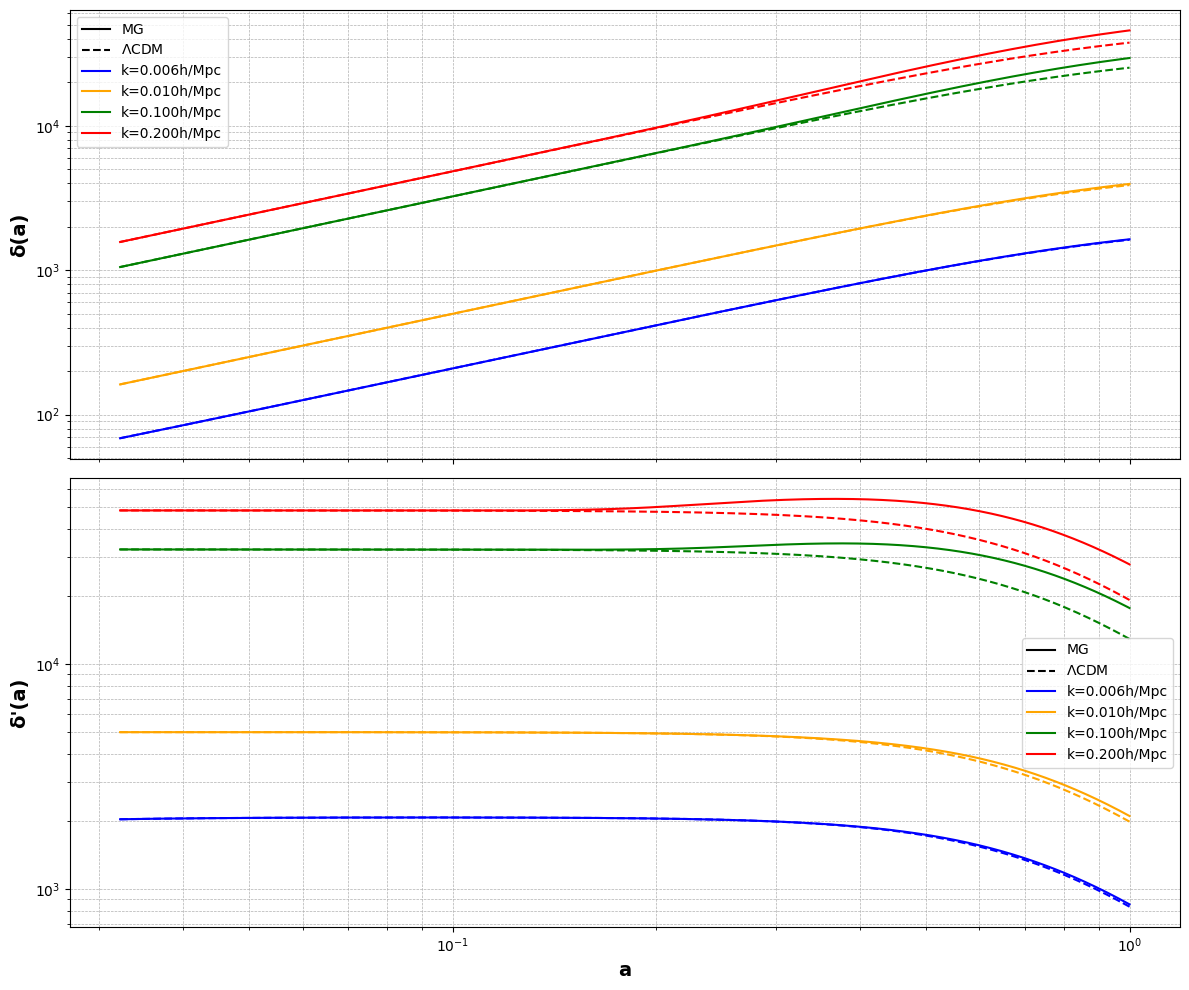

In [6]:
from matplotlib.lines import Line2D


k_thresholds = np.array([.006,.01,.1,.3])/h #1/Mpc
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
# lista_dif_rel =[]
# arrs_difs = np.zeros((len(k_thresholds), len(df['a'].unique())))

line_style_elements = [
    Line2D([0], [0], color='black', linestyle='-', label=r'$\rm MG$'),
    Line2D([0], [0], color='black', linestyle='--', label=r'$\Lambda \rm CDM$')
]
line_style_elements2 = [
    Line2D([0], [0], color='black', linestyle='-', label=r'$\rm MG$'),
    Line2D([0], [0], color='black', linestyle='--', label=r'$\Lambda \rm CDM$')
]
color_elements =[]
#plot 3 delta_mg vs a_mg for 3 different ks
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
for i, k in enumerate(k_thresholds):
	idx = np.argmin(np.abs(mis_ks - k))
	axs[0].plot(a_mg, np.abs(delta_mg[idx, :]), '-', color = colors[i % len(colors)])
	axs[0].plot(a_LCDM, np.abs(delta_LCDM[idx, :]), '--', color = colors[i % len(colors)])
	axs[1].plot(a_mg, np.abs(delta_p_mg[idx, :]), '-', color = colors[i % len(colors)])
	axs[1].plot(a_LCDM, np.abs(delta_p_LCDM[idx, :]), '--', color = colors[i % len(colors)])
	color = colors[i % len(colors)]
	color_elements.append(
	Line2D([0], [0], color=color, linestyle='-', label=f'k={mis_ks[idx]*h:.3f}h/Mpc')
    )
axs[0].legend(handles=line_style_elements + color_elements)
axs[1].legend(handles=line_style_elements2 + color_elements)
axs[0].grid(True, which='both', linestyle='--', linewidth=.5)
axs[1].grid(True, which = 'both', linestyle = '--', linewidth = .5)
# axs[0].legend()	
# axs[1].legend()
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('a', fontsize=14, fontweight='bold')
axs[0].set_ylabel('δ(a)', fontsize=14, fontweight='bold')
axs[1].set_ylabel("δ'(a)", fontsize=14, fontweight='bold')
# axs[0].set_title('Matter density contrast δ_mg(a) for different k modes')
# axs[1].set_title('Matter density contrast δ_LCDM(a) for different k modes')
plt.tight_layout()
plt.show()


## $\sigma_8$(z)

### Compute cosas
Solo calcular a partir de $z=3$

In [7]:
z = 2.0
idx_z = np.argmin(np.abs(z_mg - z))
#deltas bewteen z=0 and z=2 for all ks
deltas_mg_z = delta_mg[:, idx_z:]
deltas_LCDM_z = delta_LCDM[:, idx_z:]
#delta_p between z=0 and z=2 for all ks
deltas_p_mg_z = delta_p_mg[:, idx_z:]
deltas_p_LCDM_z = delta_p_LCDM[:, idx_z:]
z_s8_idx = z_mg[idx_z:]
a_s8_idx = a_mg[idx_z:]


In [8]:
#compute sigma8
sigma8_lcdm = solver.compute_sigma8_vectorized(deltas = deltas_LCDM_z)

Process ForkPoolWorker-2196:
Process ForkPoolWorker-2195:
Process ForkPoolWorker-2197:
Process ForkPoolWorker-2198:
Process ForkPoolWorker-2194:
Process ForkPoolWorker-2193:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib

KeyboardInterrupt: 

In [ ]:
sigma8_mg = solver.compute_sigma8_vectorized(deltas = deltas_mg_z)

In [ ]:
print("sigma8(z=0) LCDM:", sigma8_lcdm[-1])
print("sigma8(z=0) MG:", sigma8_mg[-1])

sigma8(z=0) LCDM: 0.24545632430394196
sigma8(z=0) MG: 0.29058904045197437


In [73]:
#idx where z = 3
z_LCDM = 1/a_LCDM - 1
idx_lcdm = np.argmin(np.abs(z_LCDM - 3))
idx_mg = np.argmin(np.abs(z_mg - 3))

sigma8_lcdm_z3 = sigma8_lcdm[:]
sigma8_mg_z3 = sigma8_mg
z_idxs_LCDM = z_LCDM[idx_lcdm:]
z_idxs_MG = z_mg[idx_mg:]
print('sigma8(z=0) LCDM:', sigma8_lcdm[-1])
print('sigma8(z=0) MG:', sigma8_mg[-1])

sigma8(z=0) LCDM: 0.24545632430394196
sigma8(z=0) MG: 0.29058904045197437


In [80]:
#save in csv sigma8, z and a
df_sigma8 = pd.DataFrame({'a':a_s8_idx, 'z': z_s8_idx, 'sigma8_LCDM': sigma8_lcdm_z3,
						  'sigma8_MG': sigma8_mg_z3})
# df_sigma8.head()
df_sigma8.to_csv(f'{path}/sigma8_vs_z2.csv', index=False)

### Cargar cosas

In [9]:
df_sigma8 = pd.read_csv(f'{path}/sigma8_vs_z2.csv')
df_sigma8.head()

,a,z,sigma8_LCDM,sigma8_MG
0,0.332879,2.004094,0.103338,0.107128
1,0.334025,1.993785,0.103678,0.107519
2,0.335175,1.983512,0.104019,0.107911
3,0.336330,1.973274,0.104361,0.108304
4,0.337488,1.963071,0.104703,0.108699


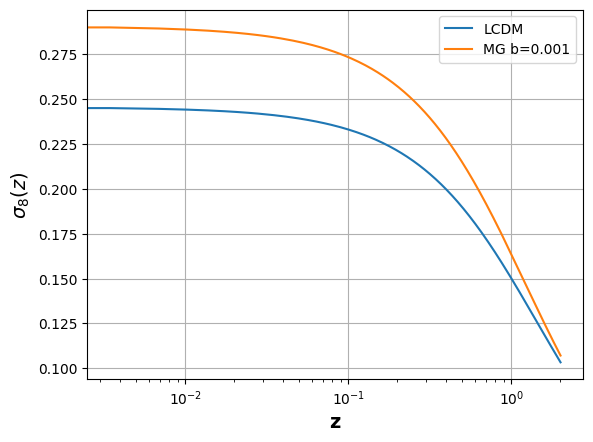

In [10]:
#plot sigma 8 vs z
z_mg_z = df_sigma8['z'].values
sigma8_lcdm = df_sigma8['sigma8_LCDM'].values
sigma8_mg = df_sigma8['sigma8_MG'].values
plt.plot(z_mg_z, sigma8_lcdm, label='LCDM')
plt.plot(z_mg_z, sigma8_mg, label='MG b=0.001')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('$\sigma_8(z)$', fontsize=14, fontweight='bold')
plt.xscale('log')
# plt.yscale('log')
# plt.title('sigma8(z) vs z')
plt.legend()
plt.grid()
plt.show()

## $f\sigma_8(z)$

In [23]:
import funciones_tesis as ft
import importlib
import sys
sys.path.append('../python/')
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
import numpy as np
import matplotlib.pyplot as plt



In [24]:
#print modules of the class and check if 'f_k' is in any of them
# print(dir(VectorizedDeltaSolver))
for attr in dir(VectorizedDeltaSolver):
	if 'f_k' in attr:
		print(attr)

compute_f_k_vectorized
compute_f_with_f_k
compute_f_with_f_k_exp


In [25]:
# mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 100)  # k en 1/Mpc
# solver = VectorizedDeltaSolver(k_array=mis_ks, h=0.68, Om_m_0=0.3, b=0.001)
# a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel()
# a_LCDM, delta_LCDM, delta_p_LCDM = solver.solve_delta_lcdm_vectorized_parallel()
# z_mg = 1/a_mg - 1

#load df from csv
df_sigma8 = pd.read_csv(f'{path}/sigma8_vs_z2.csv')
sigma8_lcdm = df_sigma8['sigma8_LCDM'].values
print(len(sigma8_lcdm))
df_sigma8.head()

321


,a,z,sigma8_LCDM,sigma8_MG
0,0.332879,2.004094,0.103338,0.107128
1,0.334025,1.993785,0.103678,0.107519
2,0.335175,1.983512,0.104019,0.107911
3,0.336330,1.973274,0.104361,0.108304
4,0.337488,1.963071,0.104703,0.108699


### f en $\Lambda CDM$


In [27]:
solver = VectorizedDeltaSolver(k_array=mis_ks, h=0.68, Om_m_0=0.3, b=0.001)

VectorizedDeltaSolver usando: cuda


In [28]:
#compute f_k
idx_z = np.argmin(np.abs(z_mg - 2.0))
a_z= a_mg[idx_z:]
# a_z= df_sigma8['a'].values
deltas_LCDM_z = delta_LCDM[:, idx_z:]
deltas_p_LCDM_z = delta_p_LCDM[:, idx_z:]

ks, z, f_k_LCDM = solver.compute_f_k_vectorized(a_vec=a_z, delta=deltas_LCDM_z, delta_p=deltas_p_LCDM_z)
print(len(f_k_LCDM[0,:]), len(z))
# print(z)


321 321


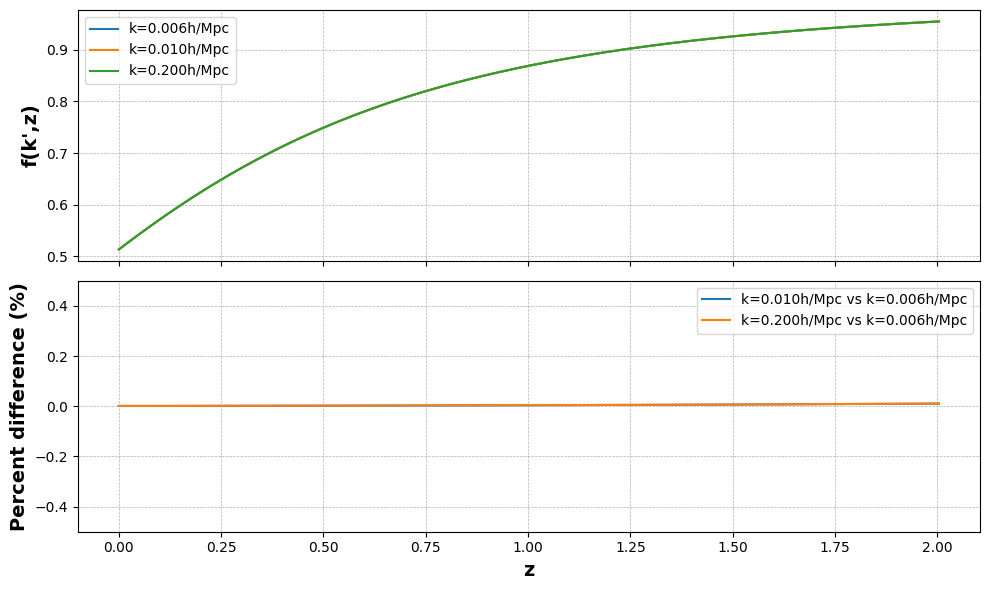

In [29]:
#plot f_k for different ks and their percent difference
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i, k in enumerate(np.array([.006,.01,.2])/solver.h):
	idx = np.argmin(np.abs(ks - k))
	axs[0].plot(z, f_k_LCDM[idx, :], label=f'k={k*solver.h:.3f}h/Mpc')
	if i > 0:
		percent_diff = (f_k_LCDM[idx, :] - f_k_LCDM[0, :]) / f_k_LCDM[0, :] * 100
		axs[1].plot(z, percent_diff, label=f'k={k*solver.h:.3f}h/Mpc vs k={ks[0]*solver.h:.3f}h/Mpc')
axs[0].set_ylabel("f(k',z)", fontsize=14, fontweight='bold')
axs[1].set_ylabel('Percent difference (%)', fontsize=14, fontweight='bold')
axs[1].set_xlabel('z', fontsize=14, fontweight='bold')
axs[0].legend()
axs[1].legend()
axs[0].grid(True, which='both', linestyle='--', linewidth=.5)
axs[1].set_ylim(-.5, .5)
axs[1].grid(True, which = 'both', linestyle = '--', linewidth = .5)
plt.tight_layout()
plt.show()
	

In [30]:
f_z_integrando = np.real(solver.compute_f_with_f_k(z_vec=z, f_k_array=f_k_LCDM, use_mg_hubble=False, k_array=ks))
f_z_debug_LCDM, H_debug_LCDM, z_debug_LCDM, x_fisico_debug_LCDM = solver.compute_f_with_f_k(z_vec=z, f_k_array=f_k_LCDM, use_mg_hubble=False, k_array=ks, debug=True)
print(len(f_z_integrando), len(z))
# f_z_integrando

/home/pedrorozin/scripts/python/delta_solver_mg_pedro.py:1056: RuntimeWarning: divide by zero encountered in log10
  z_int = np.logspace(np.log10(0.0001), np.log10(z), 1000)
/home/pedrorozin/scripts/venv/lib/python3.10/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step


DEBUG: Calculando distancias físicas x(z)
En z=2.00, x(z)=5336.88 Mpc. La integral (sin ctes).: 1.21 Mpc
En z=1.90, x(z)=5182.77 Mpc. La integral (sin ctes).: 1.18 Mpc
En z=1.80, x(z)=5026.69 Mpc. La integral (sin ctes).: 1.14 Mpc
En z=1.71, x(z)=4868.68 Mpc. La integral (sin ctes).: 1.10 Mpc
En z=1.62, x(z)=4708.79 Mpc. La integral (sin ctes).: 1.07 Mpc
En z=1.53, x(z)=4547.10 Mpc. La integral (sin ctes).: 1.03 Mpc
En z=1.44, x(z)=4383.66 Mpc. La integral (sin ctes).: 0.99 Mpc
En z=1.36, x(z)=4218.56 Mpc. La integral (sin ctes).: 0.96 Mpc
En z=1.28, x(z)=4051.90 Mpc. La integral (sin ctes).: 0.92 Mpc
En z=1.20, x(z)=3883.78 Mpc. La integral (sin ctes).: 0.88 Mpc
En z=1.13, x(z)=3714.31 Mpc. La integral (sin ctes).: 0.84 Mpc
En z=1.06, x(z)=3543.62 Mpc. La integral (sin ctes).: 0.80 Mpc
En z=0.99, x(z)=3371.85 Mpc. La integral (sin ctes).: 0.76 Mpc
En z=0.92, x(z)=3199.15 Mpc. La integral (sin ctes).: 0.73 Mpc
En z=0.86, x(z)=3025.69 Mpc. La integral (sin ctes).: 0.69 Mpc
En z=0.79, x(

In [31]:
#difference between f(z) from f_k and f(z) from delta at the start
dif_ini= f_k_LCDM[0, 0]/f_z_integrando[0]
mean_dif = np.mean(f_k_LCDM[0, :-1]/f_z_integrando[:-1])
print("Difference at z ini:", dif_ini)
print("Mean difference over z:", mean_dif)
print(dif_ini, 2*np.pi**2, 1/(solver.h**3))
print(4*np.pi**2/solver.h**3)

Difference at z ini: 12958455.656272605
Mean difference over z: 625089.5620226087
12958455.656272605 19.739208802178716 3.1803378790962746
125.55470691391915


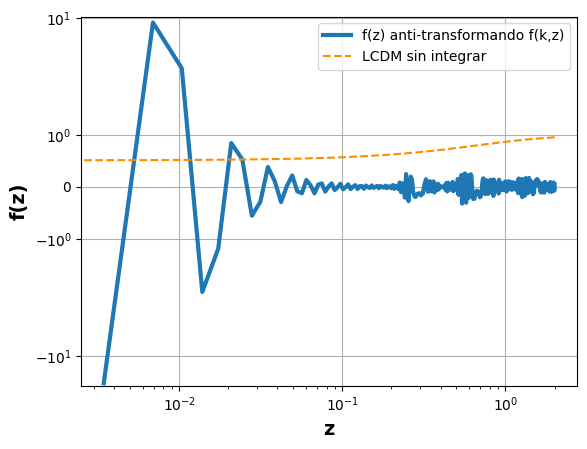

In [32]:
plt.plot(z, f_z_integrando*mean_dif, label='f(z) anti-transformando f(k,z)', linewidth=3)
plt.plot(z, f_k_LCDM[-1, :],'--',color ='darkorange', label='LCDM sin integrar')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('f(z)', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.yscale('symlog')
plt.legend()
plt.grid()
plt.show()

### $f\sigma_8(z)$ para $\Lambda CDM$:

Para LCDM da bien la pinta funcional si usamos que es scale-dependent (hay una constante que molesta todavía). El problema está en la transformada de Fourier de f_k

<!-- Nota: cuando hago $\Lambda CDM$, estoy calculando: $'f\sigma_8(z)' = a(z) \frac{\delta '(z)}{\delta (z=0)}  $ (no estoy multiplicando por $\sigma_8$ todavía) -->

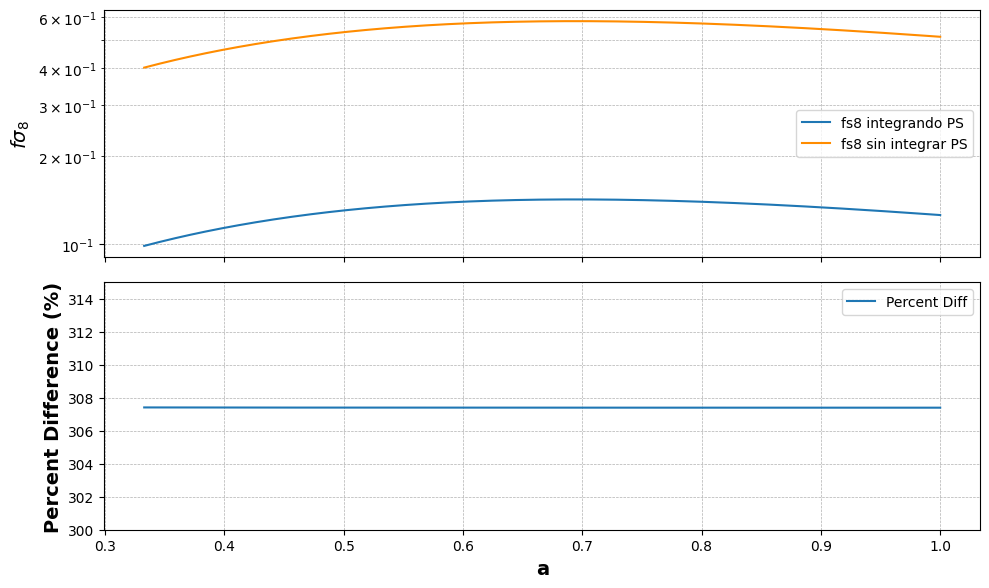

In [33]:
fsigma8_de_siempre = deltas_p_LCDM_z[0,:] / deltas_LCDM_z[0,-1] * a_z
f_sigma8_LCDM = f_k_LCDM[0,:] * sigma8_lcdm
percent_difference = np.abs(f_sigma8_LCDM - fsigma8_de_siempre) / f_sigma8_LCDM * 100
ratio_medio = np.mean(fsigma8_de_siempre / f_sigma8_LCDM)
fsigma8_de_siempre_norm = fsigma8_de_siempre / ratio_medio
dif_normalizada = np.abs(f_sigma8_LCDM - fsigma8_de_siempre_norm) / f_sigma8_LCDM * 100
fig, ax =plt.subplots(2,1, figsize=(10,6), sharex=True)
#plot both fs8 and percent difference
# ax[0].plot(a_z, fsigma8_de_siempre, label='fs8 sin integrar PS')

ax[0].plot(a_z, f_sigma8_LCDM, label='fs8 integrando PS')
ax[0].plot(a_z, fsigma8_de_siempre, label='fs8 sin integrar PS', color ='darkorange')
# ax[0].plot(a_z, fsigma8_de_siempre_norm, label='fs8 sin integrar PS (normalizado)', linestyle='--', color ='darkorange')
#grid and logscale
ax[0].grid(True, which='both', linestyle='--', linewidth=.5)
ax[0].set_yscale('log')
ax[0].legend()
# ax[0].set_xlabel('a')
ax[0].set_ylabel('$f\sigma_8$', fontsize=14, fontweight='bold')

ax[1].plot(a_z, percent_difference, label='Percent Diff')
# ax[1].plot(a_z, dif_normalizada, label='Percent Diff.',  color='darkorange')
#scale between 0 and 15
ax[1].set_ylim(300, 315)
# ax[1].set_ylim(-.5, .5)
ax[1].grid(True, which='both', linestyle='--', linewidth=.5)
ax[1].set_xlabel('a', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Percent Difference (%)', fontsize=14, fontweight='bold')
ax[1].legend()

plt.tight_layout()
plt.show()

h^3 = 0.31443200000000004
ratio medio fs8 (f_k/sigma8) / fs8 (de siempre): 0.2454536309287119


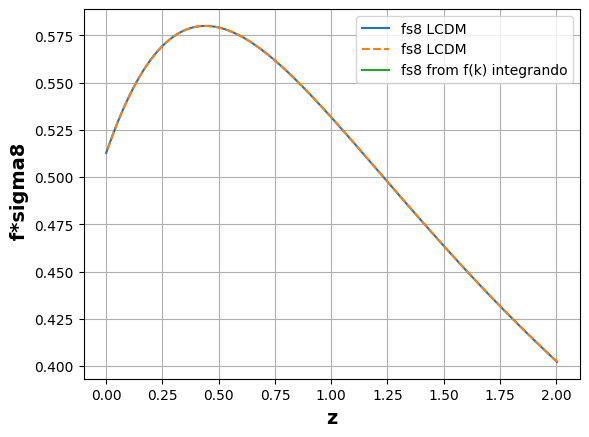

In [34]:
fsigma8_de_siempre = deltas_p_LCDM_z[0,:] / deltas_LCDM_z[0,-1] * a_z
f_sigma8_LCDM = f_k_LCDM[0,:] * sigma8_lcdm
f_sigma8_integrando = f_z_integrando * sigma8_lcdm
ratio_medio = np.mean(f_sigma8_LCDM/fsigma8_de_siempre)
ratio_medio2= np.mean(f_sigma8_integrando/fsigma8_de_siempre)
print(f'h^3 = {solver.h**3}')
print("ratio medio fs8 (f_k/sigma8) / fs8 (de siempre):", ratio_medio)
plt.plot(z, f_sigma8_LCDM/ratio_medio, label='fs8 LCDM')
# plt.plot(z, f_sigma8_LCDM, label='fs8 LCDM integrando PS', linewidth=3)
plt.plot(z, fsigma8_de_siempre, '--', label='fs8 LCDM')
plt.plot(z, f_sigma8_integrando/ratio_medio2, label='fs8 from f(k) integrando')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel(' f*sigma8', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

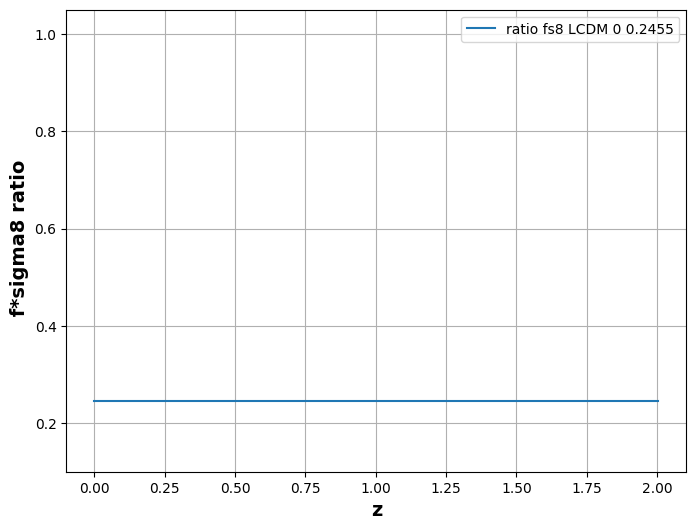

In [35]:
plt.figure(figsize=(8,6))
plt.plot(z, f_sigma8_LCDM/fsigma8_de_siempre, label=f'ratio fs8 LCDM 0 {np.mean(f_sigma8_LCDM/fsigma8_de_siempre):.4f}')
plt.ylim(0.1, 1.05)
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel(' f*sigma8 ratio', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

## $f\sigma_8(z)$ integrando $f_k$

In [37]:
# f_LCDM_clase = solver.compute_f_with_f_k(z,f_k_LCDM)
f_LCDM_clase, _ ,__,___ = solver.compute_f_with_f_k(z,f_k_LCDM, debug=True)


/home/pedrorozin/scripts/python/delta_solver_mg_pedro.py:1056: RuntimeWarning: divide by zero encountered in log10
  z_int = np.logspace(np.log10(0.0001), np.log10(z), 1000)
/home/pedrorozin/scripts/venv/lib/python3.10/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step


DEBUG: Calculando distancias físicas x(z)
En z=2.00, x(z)=5336.48 Mpc. La integral (sin ctes).: 1.21 Mpc
En z=1.90, x(z)=5182.38 Mpc. La integral (sin ctes).: 1.18 Mpc
En z=1.80, x(z)=5026.31 Mpc. La integral (sin ctes).: 1.14 Mpc
En z=1.71, x(z)=4868.31 Mpc. La integral (sin ctes).: 1.10 Mpc
En z=1.62, x(z)=4708.44 Mpc. La integral (sin ctes).: 1.07 Mpc
En z=1.53, x(z)=4546.76 Mpc. La integral (sin ctes).: 1.03 Mpc
En z=1.44, x(z)=4383.34 Mpc. La integral (sin ctes).: 0.99 Mpc
En z=1.36, x(z)=4218.27 Mpc. La integral (sin ctes).: 0.96 Mpc
En z=1.28, x(z)=4051.62 Mpc. La integral (sin ctes).: 0.92 Mpc
En z=1.20, x(z)=3883.52 Mpc. La integral (sin ctes).: 0.88 Mpc
En z=1.13, x(z)=3714.07 Mpc. La integral (sin ctes).: 0.84 Mpc
En z=1.06, x(z)=3543.39 Mpc. La integral (sin ctes).: 0.80 Mpc
En z=0.99, x(z)=3371.64 Mpc. La integral (sin ctes).: 0.76 Mpc
En z=0.92, x(z)=3198.96 Mpc. La integral (sin ctes).: 0.73 Mpc
En z=0.86, x(z)=3025.51 Mpc. La integral (sin ctes).: 0.69 Mpc
En z=0.79, x(

In [159]:
solver.b

0.001

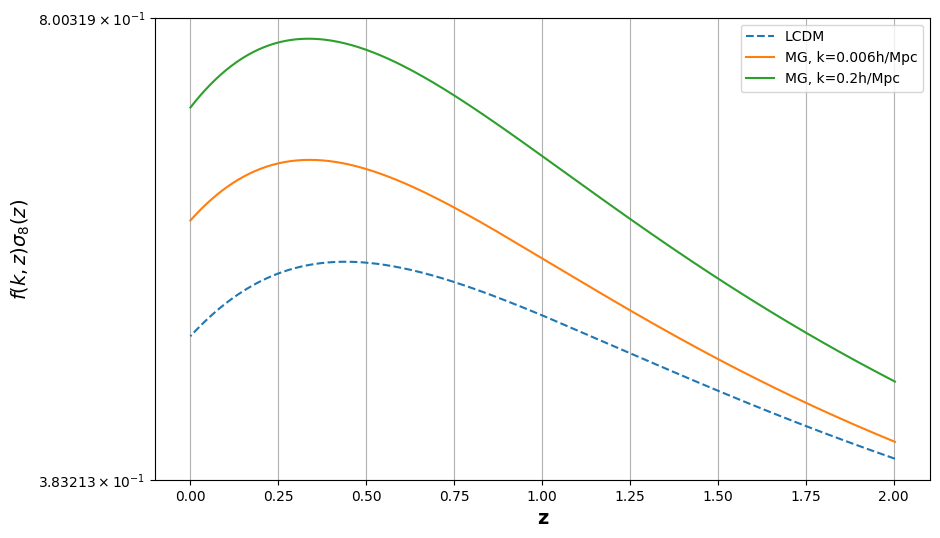

In [169]:
#compute f_k of delta_mg
sigma8_mg = df_sigma8['sigma8_MG'].values
sigma8_LCDM = df_sigma8['sigma8_LCDM'].values
deltas_mg_z = delta_mg[:, idx_z:]
deltas_p_mg_z = delta_p_mg[:, idx_z:]
ks_mg, _z_mg, f_k_mg = solver.compute_f_k_vectorized(a_vec=a_z, delta=deltas_mg_z, delta_p=deltas_p_mg_z)


plt.figure(figsize=(10,6))
plt.plot(z, f_k_LCDM[0,:]*sigma8_LCDM/ratio_medio, '--', label='LCDM')
# plt.plot(z, f_LCDM_clase, ':', label='f LCDM int')
plt.plot(z, f_k_mg[0,:]*sigma8_mg/ratio_medio, label ='MG, k=0.006h/Mpc')
plt.plot(z, f_k_mg[-1,:]*sigma8_mg/ratio_medio, label ='MG, k=0.2h/Mpc')
#ylims
# plt.ylim(0, 1.1)
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel(f'$f(k,z) \sigma_8(z)$ ', fontsize=14, fontweight='bold')
# plt.xscale('log')
plt.yscale('symlog')
plt.legend()
plt.grid()
plt.show()

## $f \sigma_8$ para MG

In [155]:
sigma8_mg = df_sigma8['sigma8_MG'].values
f_mg_antitransform = solver.compute_f_with_f_k(z_mg_z, f_k_mg)
f_z_debug_MG, H_debug_MG, z_debug_MG, x_fisico_debug_MG = solver.compute_f_with_f_k(z_mg_z, f_k_mg, debug=True)
fsigma8_mg = f_mg_antitransform * sigma8_mg


DEBUG: Calculando distancias físicas x(z)
En z=2.00, x(z)=5336.48 Mpc. Sin ctes.: 1.21 Mpc
En z=1.90, x(z)=5182.38 Mpc. Sin ctes.: 1.18 Mpc
En z=1.80, x(z)=5026.31 Mpc. Sin ctes.: 1.14 Mpc
En z=1.71, x(z)=4868.31 Mpc. Sin ctes.: 1.10 Mpc
En z=1.62, x(z)=4708.44 Mpc. Sin ctes.: 1.07 Mpc
En z=1.53, x(z)=4546.76 Mpc. Sin ctes.: 1.03 Mpc
En z=1.44, x(z)=4383.34 Mpc. Sin ctes.: 0.99 Mpc
En z=1.36, x(z)=4218.27 Mpc. Sin ctes.: 0.96 Mpc
En z=1.28, x(z)=4051.62 Mpc. Sin ctes.: 0.92 Mpc
En z=1.20, x(z)=3883.52 Mpc. Sin ctes.: 0.88 Mpc
En z=1.13, x(z)=3714.07 Mpc. Sin ctes.: 0.84 Mpc
En z=1.06, x(z)=3543.39 Mpc. Sin ctes.: 0.80 Mpc
En z=0.99, x(z)=3371.64 Mpc. Sin ctes.: 0.76 Mpc
En z=0.92, x(z)=3198.96 Mpc. Sin ctes.: 0.73 Mpc
En z=0.86, x(z)=3025.51 Mpc. Sin ctes.: 0.69 Mpc
En z=0.79, x(z)=2851.47 Mpc. Sin ctes.: 0.65 Mpc
En z=0.73, x(z)=2677.01 Mpc. Sin ctes.: 0.61 Mpc
En z=0.67, x(z)=2502.34 Mpc. Sin ctes.: 0.57 Mpc
En z=0.62, x(z)=2327.65 Mpc. Sin ctes.: 0.53 Mpc
En z=0.56, x(z)=2153.16 Mpc

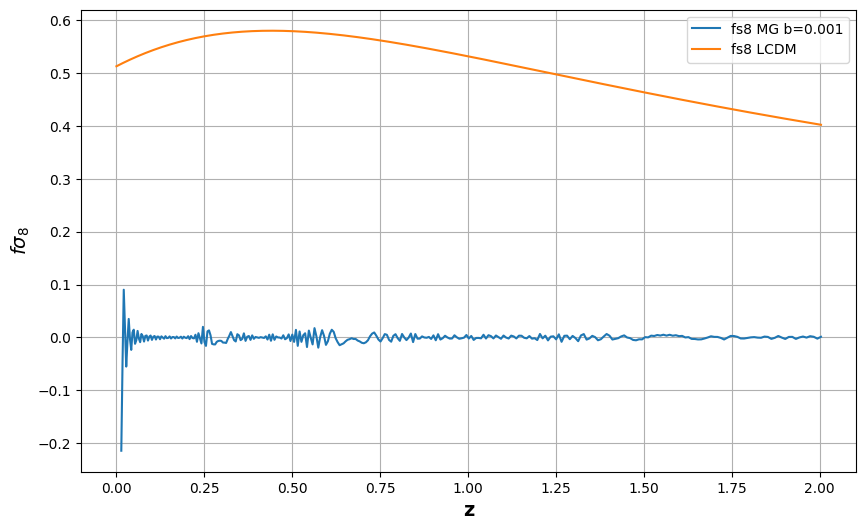

In [42]:
plt.figure(figsize=(10,6))
plt.plot(z_mg_z[:-4], fsigma8_mg[:-4]/ratio_medio2 , label='fs8 MG b=0.001')
plt.plot(z_mg_z, fsigma8_de_siempre, label='fs8 LCDM')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel(f'$f\sigma_8$', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

### Debug: veo el $H(z)$ que se está calculando para MG y LCDM 

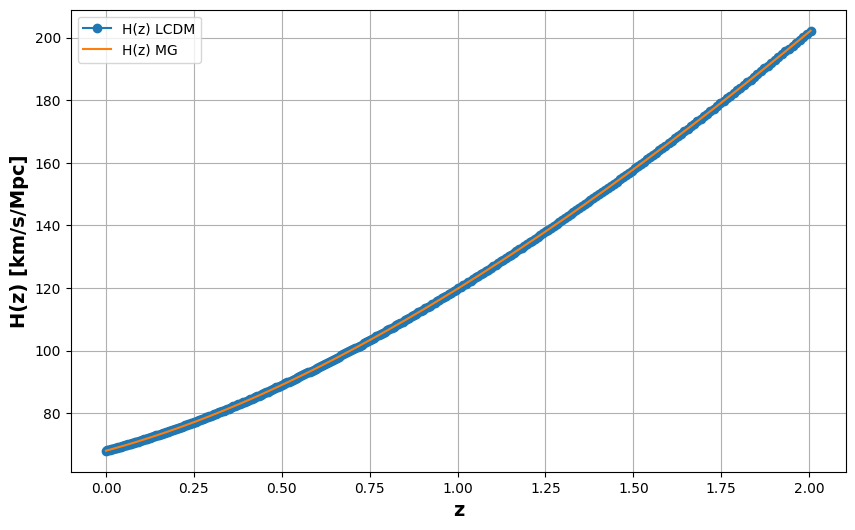

In [137]:
#plot H_debug_LCDM and H_debug_MG vs z
plt.figure(figsize=(10,6))
plt.plot(z_debug_LCDM, H_debug_LCDM, label='H(z) LCDM', marker='o')
plt.plot(z_debug_MG, H_debug_MG, label='H(z) MG')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('H(z) [km/s/Mpc]', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()
# --- IGNORE ---

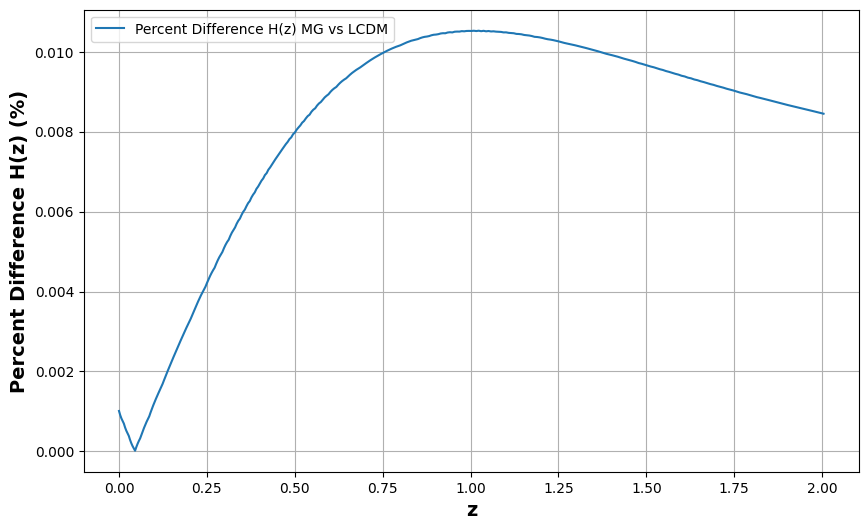

In [72]:
plt.figure(figsize=(10,6))
percent_diff_H = np.abs(H_debug_MG - H_debug_LCDM) / H_debug_LCDM * 100
plt.plot(z_debug_LCDM, percent_diff_H, label='Percent Difference H(z) MG vs LCDM')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('Percent Difference H(z) (%)', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

# Gran debug: corro todo para k's muy pequeños que no están en nuestra aprox-

In [73]:
h=0.68
mis_ks_debug = np.logspace(np.log10(0.00000000001), np.log10(0.2), 1000)/h  # k en 1/Mpc
solver_debug = VectorizedDeltaSolver(k_array=mis_ks_debug, h=h, Om_m_0=0.3, b=0.001)

VectorizedDeltaSolver usando: cuda


## Deltas

### Compute cosas (NO CORRER POR ERROR):

In [74]:
	
a_mg_debug, delta_mg_debug, delta_p_mg_debug = solver_debug.solve_delta_mg_vectorized_parallel()
a_LCDM_debug, delta_LCDM_debug, delta_p_LCDM_debug = solver_debug.solve_delta_lcdm_vectorized_parallel()
z_mg_debug = 1/a_mg_debug - 1
#guardar todos estos arrays de la manera mas eficiente para importarlos luego
path = '/home/pedrorozin/scripts/outputs_pedro/modified_gravity'
file_name = 'delta_mg_vs_k_and_z_debug.npz'
np.savez_compressed(path + f'/{file_name}', mis_ks=mis_ks_debug, a_mg=a_mg_debug, delta_mg=delta_mg_debug, delta_p_mg=delta_p_mg_debug,
					a_LCDM=a_LCDM_debug, delta_LCDM=delta_LCDM_debug, delta_p_LCDM=delta_p_LCDM_debug, z_mg=z_mg_debug)

#guardar info en un txt
with open(path + f'/{file_name}_info.txt', 'w') as f:
	f.write('Arrays guardados:\n')
	f.write('mis_ks: array de k en 1/Mpc\n')
	f.write('a_mg: array de a para MG\n')
	f.write('delta_mg: array de delta para MG\n')
	f.write('delta_p_mg: array de d(delta)/da para MG\n')
	f.write('a_LCDM: array de a para LCDM\n')
	f.write('delta_LCDM: array de delta para LCDM\n')
	f.write('delta_p_LCDM: array de d(delta)/da para LCDM\n')
	f.write('z_mg: array de z correspondiente a a_mg\n')
	f.write('\nDimensiones:\n')
	f.write(f'mis_ks: {mis_ks_debug.shape}\n')
	f.write(f'a_mg: {a_mg_debug.shape}\n')
	f.write(f'delta_mg: {delta_mg_debug.shape}\n')
	f.write(f'delta_p_mg: {delta_p_mg_debug.shape}\n')
	f.write(f'a_LCDM: {a_LCDM_debug.shape}\n')
	f.write(f'delta_LCDM: {delta_LCDM_debug.shape}\n')
	f.write(f'delta_p_LCDM: {delta_p_LCDM_debug.shape}\n')
	f.write(f'z_mg: {z_mg_debug.shape}\n')
	f.write(f'\nParametros usados:\n')
	f.write(f'h: {solver_debug.h}\n')
	f.write(f'Om_m_0: {solver_debug.Om_m_0}\n')
	f.write(f'b: {solver_debug.b}\n')
print(f"Arrays guardados en {path + f'/{file_name}'} y {path + f'/{file_name}_info.txt'}")

Resolviendo 1000 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1000 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
Arrays guardados en /home/pedrorozin/scripts/outputs_pedro/modified_gravity/delta_mg_vs_k_and_z_debug.npz y /home/pedrorozin/scripts/outputs_pedro/modified_gravity/delta_mg_vs_k_and_z_debug.npz_info.txt


### Correr para cargar soluciones guardadas:

In [75]:
#load the arrays
path = '/home/pedrorozin/scripts/outputs_pedro/modified_gravity'
data = np.load(path + '/delta_mg_vs_k_and_z_debug.npz')
mis_ks_debug = data['mis_ks']
a_mg_debug = data['a_mg']
delta_mg_debug = data['delta_mg']
delta_p_mg_debug = data['delta_p_mg']
a_LCDM_debug = data['a_LCDM']
delta_LCDM_debug = data['delta_LCDM']
delta_p_LCDM_debug = data['delta_p_LCDM']
z_mg_debug = data['z_mg']

# print shapes
print(f"mis_ks: {mis_ks_debug.shape}")
print(f"a_mg: {a_mg_debug.shape}")
print(f"delta_mg: {delta_mg_debug.shape}")
print(f"delta_p_mg: {delta_p_mg_debug.shape}")
print(f"a_LCDM: {a_LCDM_debug.shape}")
print(f"delta_LCDM: {delta_LCDM_debug.shape}")
print(f"delta_p_LCDM: {delta_p_LCDM_debug.shape}")
print(f"z_mg: {z_mg_debug.shape}")
##print z ini
print(f"z_mg ini: {z_mg_debug[0]:.2f}, z_mg fin: {z_mg_debug[-1]:.2f}")

mis_ks: (1000,)
a_mg: (1000,)
delta_mg: (1000, 1000)
delta_p_mg: (1000, 1000)
a_LCDM: (1000,)
delta_LCDM: (1000, 1000)
delta_p_LCDM: (1000, 1000)
z_mg: (1000,)
z_mg ini: 30.00, z_mg fin: 0.00


## $\sigma_8$(z)

### Compute cosas
Solo calcular a partir de $z=2$

In [76]:
z = 2.0
idx_z = np.argmin(np.abs(z_mg_debug - z))
#deltas bewteen z=0 and z=2 for all ks
deltas_mg_z_debug = delta_mg_debug[:, idx_z:]
deltas_LCDM_z_debug = delta_LCDM_debug[:, idx_z:]
#delta_p between z=0 and z=2 for all ks
deltas_p_mg_z_debug = delta_p_mg_debug[:, idx_z:]
deltas_p_LCDM_z_debug = delta_p_LCDM_debug[:, idx_z:]
z_s8_idx = z_mg_debug[idx_z:]
a_s8_idx = a_mg_debug[idx_z:]


In [77]:
#compute sigma8
sigma8_lcdm_debug = solver.compute_sigma8_vectorized(deltas = deltas_LCDM_z_debug, z_start=z)

In [78]:
sigma8_mg_debug = solver.compute_sigma8_vectorized(deltas = deltas_mg_z_debug, z_start=z)

In [79]:
print("sigma8(z=0) LCDM:", sigma8_lcdm[-1])
print("sigma8(z=0) MG:", sigma8_mg[-1])

sigma8(z=0) LCDM: 0.2454563243039419
sigma8(z=0) MG: 0.2905890404519743


In [80]:
#idx where z = 2
z_LCDM_debug = 1/a_LCDM_debug - 1
idx_lcdm = np.argmin(np.abs(z_LCDM_debug - z))
idx_mg = np.argmin(np.abs(z_mg_debug - z))

sigma8_lcdm_z2_debug = sigma8_lcdm_debug #la funcion ya tiene sigma8 desde z=2 a z=0
sigma8_mg_z2_debug = sigma8_mg_debug
z_idxs_LCDM = z_LCDM_debug[idx_lcdm:]
z_idxs_MG = z_mg_debug[idx_mg:]
print('sigma8(z=0) LCDM:', sigma8_lcdm_debug[-1])
print('sigma8(z=0) MG:', sigma8_mg_debug[-1])

sigma8(z=0) LCDM: 0.10259939208572107
sigma8(z=0) MG: 0.118557903297472


In [81]:
#save in csv sigma8, z and a
df_sigma8 = pd.DataFrame({'a':a_s8_idx, 'z': z_s8_idx, 'sigma8_LCDM': sigma8_lcdm_debug,
						  'sigma8_MG': sigma8_mg_debug})
# df_sigma8.head()
df_sigma8.to_csv(f'{path}/sigma8_vs_z_debug.csv', index=False)

### Cargar cosas

In [82]:
df_sigma8 = pd.read_csv(f'{path}/sigma8_vs_z_debug.csv')
df_sigma8.head()

,a,z,sigma8_LCDM,sigma8_MG
0,0.332879,2.004094,0.043195,0.044360
1,0.334025,1.993785,0.043337,0.044518
2,0.335175,1.983512,0.043479,0.044678
3,0.336330,1.973274,0.043622,0.044837
4,0.337488,1.963071,0.043765,0.044997


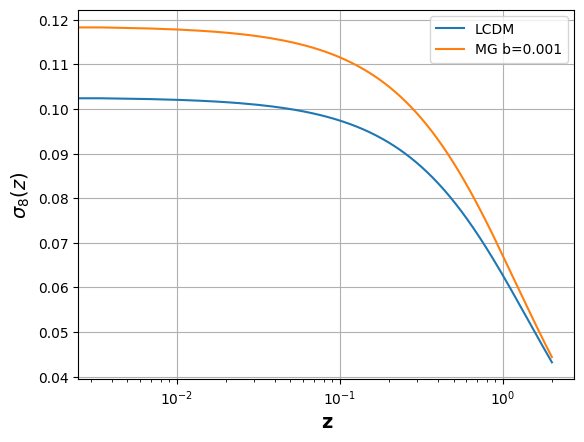

In [84]:
#plot sigma 8 vs z
z_mg_z = df_sigma8['z'].values
sigma8_lcdm_debug = df_sigma8['sigma8_LCDM'].values
sigma8_mg_debug = df_sigma8['sigma8_MG'].values
plt.plot(z_mg_z, sigma8_lcdm_debug, label='LCDM')
plt.plot(z_mg_z, sigma8_mg_debug, label='MG b=0.001')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('$\sigma_8(z)$', fontsize=14, fontweight='bold')
plt.xscale('log')
# plt.yscale('log')
# plt.title('sigma8(z) vs z')
plt.legend()
plt.grid()
plt.show()

## f y $f\sigma_8$

### En el espacio de Fourier:

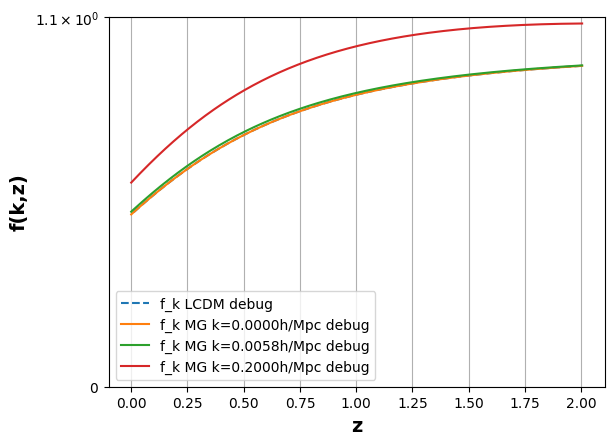

In [107]:
k_debug, z_debug, f_k_LCDM_debug = solver_debug.compute_f_k_vectorized(a_vec=a_z, delta=deltas_LCDM_z_debug, delta_p=deltas_p_LCDM_z_debug)
k_debug_MG, z_debug_MG, f_k_MG_debug = solver_debug.compute_f_k_vectorized(a_vec=a_z, delta=deltas_mg_z_debug, delta_p=deltas_p_mg_z_debug)

plt.plot(z_debug, f_k_LCDM_debug[0,:], '--', label='f_k LCDM debug')
# plt.plot(z, f_LCDM_clase, ':', label='f LCDM int')
plt.plot(z_debug_MG, f_k_MG_debug[0,:], label =f'f_k MG k={k_debug_MG[0]*h:.4f}h/Mpc debug')
plt.plot(z_debug_MG, f_k_MG_debug[ 850,:], label =f'f_k MG k={k_debug_MG[850]*h:.4f}h/Mpc debug')
plt.plot(z_debug_MG, f_k_MG_debug[-1,:], label =f'f_k MG k={k_debug_MG[-1]*h:.4f}h/Mpc debug')
#ylims
plt.ylim(0, 1.1)
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('f(k,z)', fontsize=14, fontweight='bold')
# plt.xscale('log')
plt.yscale('symlog')
plt.legend()
plt.grid()
plt.show()


### Transformando:

DEBUG: Calculando distancias físicas x(z)
En z=2.00, x(z)=5337.32 Mpc. Sin ctes.: 1.21 Mpc
En z=1.90, x(z)=5183.21 Mpc. Sin ctes.: 1.18 Mpc
En z=1.80, x(z)=5027.13 Mpc. Sin ctes.: 1.14 Mpc
En z=1.71, x(z)=4869.12 Mpc. Sin ctes.: 1.10 Mpc
En z=1.62, x(z)=4709.23 Mpc. Sin ctes.: 1.07 Mpc
En z=1.53, x(z)=4547.54 Mpc. Sin ctes.: 1.03 Mpc
En z=1.44, x(z)=4384.10 Mpc. Sin ctes.: 0.99 Mpc
En z=1.36, x(z)=4219.01 Mpc. Sin ctes.: 0.96 Mpc
En z=1.28, x(z)=4052.35 Mpc. Sin ctes.: 0.92 Mpc
En z=1.20, x(z)=3884.22 Mpc. Sin ctes.: 0.88 Mpc
En z=1.13, x(z)=3714.75 Mpc. Sin ctes.: 0.84 Mpc
En z=1.06, x(z)=3544.06 Mpc. Sin ctes.: 0.80 Mpc
En z=0.99, x(z)=3372.29 Mpc. Sin ctes.: 0.76 Mpc
En z=0.92, x(z)=3199.59 Mpc. Sin ctes.: 0.73 Mpc
En z=0.86, x(z)=3026.13 Mpc. Sin ctes.: 0.69 Mpc
En z=0.79, x(z)=2852.06 Mpc. Sin ctes.: 0.65 Mpc
En z=0.73, x(z)=2677.59 Mpc. Sin ctes.: 0.61 Mpc
En z=0.67, x(z)=2502.90 Mpc. Sin ctes.: 0.57 Mpc
En z=0.62, x(z)=2328.20 Mpc. Sin ctes.: 0.53 Mpc
En z=0.56, x(z)=2153.69 Mpc

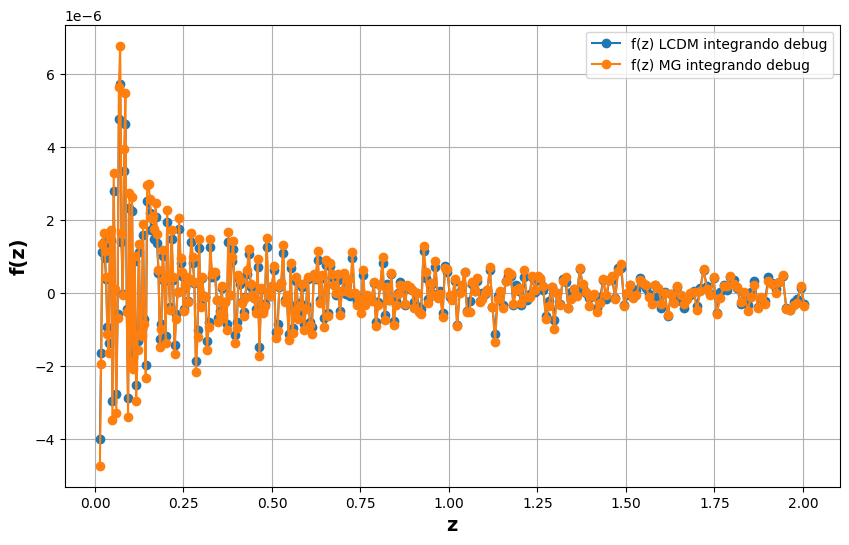

In [111]:
f_z_LCDM_integrando_debug, H_lcdm_debug, z_lcdm_debug, x_lcdm_debug = solver_debug.compute_f_with_f_k(z_vec=z_debug_LCDM, f_k_array=f_k_LCDM_debug,
																									   use_mg_hubble=False, k_array=k_debug, debug = True)
f_z_MG_integrando_debug, H_mg_debug, z_mg_debug2, x_mg_debug = solver_debug.compute_f_with_f_k(z_vec=z_debug_MG, f_k_array=f_k_MG_debug,
																							    use_mg_hubble=True, k_array=k_debug_MG, debug = True)
# f_z_debug_MG, H_debug_MG, z_debug_MG, x_fisico_debug_MG = solver.compute_f_with_f_k(z_debug_MG, f_k_MG_debug, debug=True)

plt.figure(figsize=(10,6))
plt.plot(z_debug_LCDM[:-4], f_z_LCDM_integrando_debug[:-4], label='f(z) LCDM integrando debug', marker='o')
plt.plot(z_debug_MG[:-4], f_z_MG_integrando_debug[:-4], label='f(z) MG integrando debug', marker='o')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('f(z)', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

# #diference between f_z_LCDM_integrando_debug and f_z_MG_integrando_debug
# percent_diff_f_z = np.abs(f_z_LCDM_integrando_debug - f_k_LCDM_debug[0,:]) / f_k_LCDM_debug[0,:] * 100
# plt.figure(figsize=(10,6))
# plt.plot(z_debug_MG, percent_diff_f_z, label='Percent Difference f(z) MG vs LCDM debug')
# plt.xlabel('z', fontsize=14, fontweight='bold')
# plt.ylabel('Percent Difference f(z) (%)', fontsize=14, fontweight='bold')
# plt.grid()
# plt.legend()
# plt.show()

## Cosas para calcular $\sigma_8 (z)$

- $\sigma_8 ^2 (z) = \frac{1}{2 \pi ^2} \int_{k_{hor}}^{k_{NL}}P(k,z)|\frac{3j_1(kR)}{kR}|^2k^2dk$
esto sale de Kamionkowski.
 $R=8h^{-1}$, pero entiendo que acá $[k]=h/Mpc$, y yo tengo que meterle sin $h$ al $P_k$ (porque así entran a $\delta $) $\Rightarrow$ hay que hacer cambio de variable $ k'=kh$ (da mal de cualquier forma)

$ \Rightarrow \sigma_8 ^2 (z) = \frac{1}{2 \pi ^2} \int_{k_{hor}'}^{k_{NL}'}P(k',z)|\frac{3j_1(k'R)}{k'R}|^2k'^2dk'/h^3 $

- $\frac{3j_1(kR)}{kR} = W(k)$ es la window function

- $P(k,z) = A_s k^{ns} |\delta_{CLASS}(k,z)|^2$